In [1]:
### Multi-Task Regression: Beijing climate data set
library(glmnet) # lasso and ridge regression
library(grpreg) # group lasso multi-task regression
library(rrr)    # reduced-rank regression
library(dplyr)
library(ggplot2)
library(tidyverse)

Loading required package: Matrix

Loaded glmnet 4.1-10


Attaching package: ‘rrr’


The following object is masked from ‘package:stats’:

    residuals



Attaching package: ‘dplyr’


The following object is masked from ‘package:grpreg’:

    select


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


── Attaching core tidyverse packages ─────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ lubridate 1.9.4     ✔ tibble    3.3.1
✔ purrr     1.2.1     ✔ tidyr     1.3.2
✔ readr     2.1.6     
── Conflicts ───────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ tidyr::expand() masks Matrix::expand()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ tidyr::pack()   masks Matrix::pack()
✖ dplyr::select() masks grpreg::select()
✖ tidyr::unpack() masks Matrix::unpack()
ℹ Use the c

In [15]:
###
data_all <- readRDS("../../data/climate/data_all.rds")

In [118]:
table(data_all$wd)


    E   ENE   ESE     N    NE   NNE   NNW    NW     S    SE   SSE   SSW    SW 
27296 31139 22188 27994 39319 25596 23152 30042 17683 18365 16057 20696 26356 
    W   WNW   WSW 
15919 22156 18210 

In [17]:
# coarsening of the categorical variable wind direction
# after merging categories, wind directions are "East", "North", "West", "South"
data_all <- data_all %>%
  mutate(wd_coarse = case_match(wd,
    c("ENE", "ESE") ~ "E",
    "NNE"                ~ "N",
    "NE"                 ~ "N",                            
    "NNW"                ~ "N",
    "NW"                 ~ "N",                            
    "SE"                 ~ "S",                            
    "SSE"                ~ "S",
    "SSW"                ~ "S",
    "SW"                 ~ "S",
    "SE"                 ~ "S", 
    c("WNW", "WSW")      ~ "W",
    .default = wd
  ))

data_all$wd_coarse <- as.factor(data_all$wd_coarse)

In [18]:
table(data_all$wd_coarse)


     E      N      S      W 
 80623 146103  99157  56285 

In [19]:
# data preparation continued:
# - subsetting to station 'Nongzhanguan', 
# - extract outcome and predictor variables, set coding of wd_coarse
dat <- data_all %>% filter(data_all$station == "Nongzhanguan") %>%
                select(PM2.5, PM10, SO2, NO2, CO, O3, TEMP, PRES, RAIN, WSPM, wd_coarse)
                           
# here wind direction is converted corresponding to the sum-to-zero constraint for the regression coefficients
contrasts(dat$wd_coarse) <- contr.sum(nlevels(dat$wd_coarse))

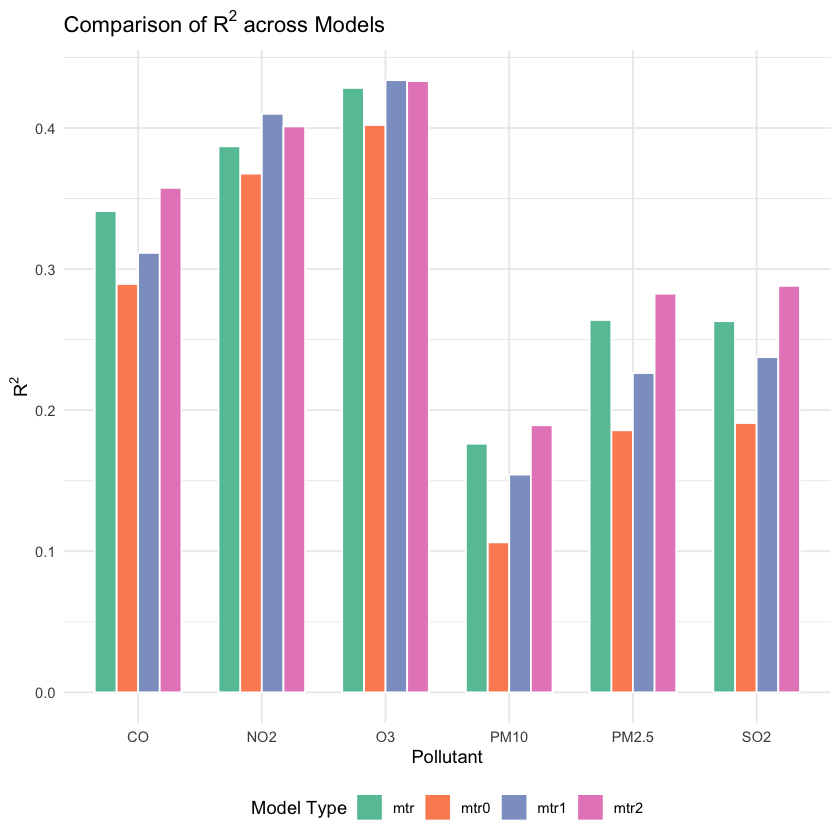

In [20]:
### some simple exploratory testing of different "candidate" models
# plain
mtr0 <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ TEMP + PRES + RAIN + WSPM, data = dat)
# quadratic terms
mtr1 <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ (TEMP + PRES + RAIN + WSPM)^2, data = dat)
# plain +  wind direction
mtr <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ TEMP + PRES + RAIN + WSPM + as.factor(wd_coarse), data = dat)
# final: same as previous, but includes interaction terms
mtr2 <- lm(log(cbind(PM2.5, PM10, SO2, NO2, CO, O3)) ~ TEMP + PRES + RAIN + (WSPM * as.factor(wd_coarse)), data = dat)

# R-squared comparisons (one for each outcome variable and model)

R2_comparison <- tibble(
  Pollutant = c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3"),
  mtr0 = unlist(lapply(summary(mtr0), function(z) z$r.squared)),
  mtr1 = unlist(lapply(summary(mtr1), function(z) z$r.squared)),
  mtr  = unlist(lapply(summary(mtr),  function(z) z$r.squared)),
  mtr2 = unlist(lapply(summary(mtr2), function(z) z$r.squared))
) %>%
  pivot_longer(
    cols = starts_with("mtr"), # Which columns to collapse
    names_to = "Model",        # The name for the new 'category' column
    values_to = "R_squared"    # The name for the new 'data' column
  )

ggplot(R2_comparison, aes(x = Pollutant, y = R_squared, fill = Model)) +
  geom_col(position = "dodge", color = "white", width = 0.7) +
  scale_fill_brewer(palette = "Set2") +
  labs(
    title = expression(paste("Comparison of ", R^2, " across Models")),
    x = "Pollutant",
    y = expression(R^2),
    fill = "Model Type"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")                         

# the model 'mtr2' achieves comparable or even better R^2's than
# the quadratic model (which has significantly more parameters)        

In [46]:
library(mvtnorm)

In [44]:
Bstar <- coef(mtr2)
svd(Bstar)$d

[1] 78.97091101  0.75934423  0.26498529  0.11850680  0.07621619  0.03842473

In [29]:
n <- nrow(dat)
d <- ncol(coef(mtr2))

In [40]:
E <- mtr2$residuals
Sigma <- crossprod(E)/ (n-d)

In [45]:
Xfull <- model.matrix(mtr2)  
Mufull <- Xfull %*% Bstar

In [55]:
set.seed(142)
Sigmafull <- (1/sqrt(10)) * Sigma
Efull <- rmvnorm(n, sigma = Sigmafull)

In [56]:
Yfull <- Mufull + Efull

In [57]:
Rsqstar <- 1 - sum(Efull^2)/(sum((Mufull - as.matrix(rep(1, n)) %*% colMeans(Mufull))^2))

In [64]:
dat[,c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")] <- exp(Yfull)

In [117]:
#write.csv(dat, sep = ",", row.names = FALSE)

Warning message in write.csv(dat, sep = ",", row.names = FALSE):
“attempt to set 'sep' ignored”
IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [69]:
lmfull <- lm(formula(mtr2), data = dat)

In [71]:
Bhat <- coef(lmfull)
Sigmahat <- crossprod(lmfull$residuals)/(n-d)

In [73]:
cov2cor(Sigmahat)

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.0000000,0.8584974,0.56063552,0.5756966,0.7849642,-0.24949216
PM10,0.8584974,1.0000000,0.53670945,0.5935454,0.6806726,-0.26376669
SO2,0.5606355,0.5367094,1.00000000,0.4400361,0.5626552,-0.01529861
NO2,0.5756966,0.5935454,0.44003611,1.0000000,0.5924454,-0.47938988
CO,0.7849642,0.6806726,0.56265524,0.5924454,1.0000000,-0.30146365
O3,-0.2494922,-0.2637667,-0.01529861,-0.4793899,-0.3014636,1.00000000


In [74]:
cov2cor(solve(Sigmahat))

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.00000000,-0.68276326,-0.06425714,0.00367802,-0.4875988,-0.03373899
PM10,-0.68276326,1.00000000,-0.11034575,-0.19415761,0.0717033,0.03310181
SO2,-0.06425714,-0.11034575,1.00000000,-0.19194197,-0.2329792,-0.27816849
NO2,0.00367802,-0.19415761,-0.19194197,1.00000000,-0.1768067,0.41762049
CO,-0.48759884,0.07170330,-0.23297917,-0.17680668,1.0000000,0.12754967
O3,-0.03373899,0.03310181,-0.27816849,0.41762049,0.1275497,1.00000000


In [77]:
# test for interaction effect 
lm_main <- lm(update(formula(mtr2), "~ . - WSPM:as.factor(wd_coarse)"), data = dat)

In [78]:
B_main <- coef(lm_main)

In [119]:
anova(lmfull, test = "Wilks")

,Df,Wilks,approx F,num Df,den Df,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1,0.001212198,4545171.0723,6,33098.00,0
TEMP,1,0.252809795,16303.7600,6,33098.00,0
PRES,1,0.716856330,2178.8395,6,33098.00,0
RAIN,1,0.950491747,287.3292,6,33098.00,0
WSPM,1,0.325360987,11438.1681,6,33098.00,0
as.factor(wd_coarse),3,0.542698784,1254.5383,18,93615.77,0
WSPM:as.factor(wd_coarse),3,0.816800052,385.7329,18,93615.77,0
Residuals,33103,NA,NA,NA,NA,NA


In [120]:
anova(lmfull, lm_main, test = "Wilks")

,Res.Df,Df,Gen.var.,Wilks,approx F,num Df,den Df,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,33103,NA,0.1183248,NA,NA,NA,NA,NA
2,33106,3,0.1223725,0.8168001,385.7329,18,93615.77,0


In [88]:
dmain <- nrow(B_main)
Sigmahat_main <- crossprod(lm_main$residuals)/(n-dmain)

In [89]:
cov2cor(Sigmahat_main)

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.0000000,0.8623227,0.59595744,0.6072169,0.8012810,-0.25567525
PM10,0.8623227,1.0000000,0.55280831,0.6161954,0.6934840,-0.27884800
SO2,0.5959574,0.5528083,1.00000000,0.4792391,0.5990944,-0.02198056
NO2,0.6072169,0.6161954,0.47923909,1.0000000,0.6216194,-0.47963008
CO,0.8012810,0.6934840,0.59909442,0.6216194,1.0000000,-0.30378824
O3,-0.2556752,-0.2788480,-0.02198056,-0.4796301,-0.3037882,1.00000000


In [90]:
cov2cor(Sigmahat)

,PM2.5,PM10,SO2,NO2,CO,O3
PM2.5,1.0000000,0.8584974,0.56063552,0.5756966,0.7849642,-0.24949216
PM10,0.8584974,1.0000000,0.53670945,0.5935454,0.6806726,-0.26376669
SO2,0.5606355,0.5367094,1.00000000,0.4400361,0.5626552,-0.01529861
NO2,0.5756966,0.5935454,0.44003611,1.0000000,0.5924454,-0.47938988
CO,0.7849642,0.6806726,0.56265524,0.5924454,1.0000000,-0.30146365
O3,-0.2494922,-0.2637667,-0.01529861,-0.4793899,-0.3014636,1.00000000


In [93]:
# drop in R^2, based on the reduced model 
R2_full <- 1 - sum(lmfull$residuals^2)/sum((Yfull - as.matrix(rep(1, n)) %*% colMeans(Yfull))^2)
#R2_main <-

In [121]:
R2_full

[1] 0.6131719

In [95]:
R2_main <- 1 - sum(lm_main$residuals^2)/sum((Yfull - as.matrix(rep(1, n)) %*% colMeans(Yfull))^2)

In [96]:
R2_main

[1] 0.585242

In [99]:
Bhat

,PM2.5,PM10,SO2,NO2,CO,O3
(Intercept),46.901413862,44.67459597,21.99435402,23.86192118,33.38153442,-12.81736190
TEMP,-0.040895908,-0.03694553,-0.06353957,-0.03123816,-0.03730832,0.06662935
PRES,-0.041510541,-0.03919840,-0.01856593,-0.01889430,-0.02531999,0.01435190
RAIN,-0.009428394,-0.04515823,-0.08906333,-0.03361817,0.01228145,0.01450527
WSPM,-0.216473837,-0.10090041,-0.01621071,-0.23667417,-0.20979312,0.41325462
as.factor(wd_coarse)1,0.250752367,0.28344338,-0.05018136,0.11904489,0.19291389,-0.46370967
as.factor(wd_coarse)2,-0.101761209,-0.15320127,-0.03439932,0.01652485,0.01516586,-0.23850157
as.factor(wd_coarse)3,0.034383001,0.06101297,0.06998222,-0.11390496,-0.03689956,0.38590939
WSPM:as.factor(wd_coarse)1,-0.013888376,-0.07943167,0.08413903,-0.02187124,0.01803941,0.12856844
WSPM:as.factor(wd_coarse)2,-0.169347195,-0.10299724,-0.20423559,-0.08805117,-0.12806181,0.04332823


In [111]:
### CCA analysis involving X and Y
X <- as.matrix(dat[,c("TEMP", "PRES", "RAIN", "WSPM")])
Y <- as.matrix(log(dat[,c("PM2.5", "PM10", "SO2",	"NO2", "CO", "O3")]))

In [112]:
ccares <- cancor(X, Y)

In [113]:
ccares

$cor
[1] 0.8764725 0.7782867 0.2957869 0.1636467

$xcoef
             [,1]          [,2]          [,3]          [,4]
TEMP 4.286940e-04  9.401489e-05  0.0007247133  0.0002707706
PRES 4.904237e-05 -2.330273e-04  0.0009249590  0.0002717908
RAIN 2.080618e-04  5.328091e-04  0.0024710025 -0.0063382877
WSPM 2.284365e-03 -3.362654e-03 -0.0014943825 -0.0006272932

$ycoef
              [,1]         [,2]          [,3]          [,4]         [,5]
PM2.5  0.000714130  0.005196877  0.0064559230  0.0009754659  0.020219288
PM10   0.002862536 -0.003352601 -0.0164152689 -0.0013850773 -0.010281497
SO2   -0.002739174 -0.005942954 -0.0005631674  0.0027927903  0.003314457
NO2   -0.002137828  0.008582139  0.0033490045  0.0194481716 -0.007621481
CO    -0.001673519  0.002995496  0.0022374717 -0.0154083425 -0.014764748
O3     0.003042069  0.002332232  0.0009255710  0.0030945677 -0.002791875
               [,6]
PM2.5 -0.0026717887
PM10  -0.0034341866
SO2    0.0044663423
NO2    0.0002350967
CO     0.0107294566
O3     0.0053254078

$xcenter
        TEMP         PRES         RAIN         WSPM 
1.369847e+01 1.012496e+03 6.689618e-02 1.858045e+00 

$ycenter
   PM2.5     PM10      SO2      NO2       CO       O3 
3.902596 4.290460 2.251062 3.848309 6.847246 3.353715

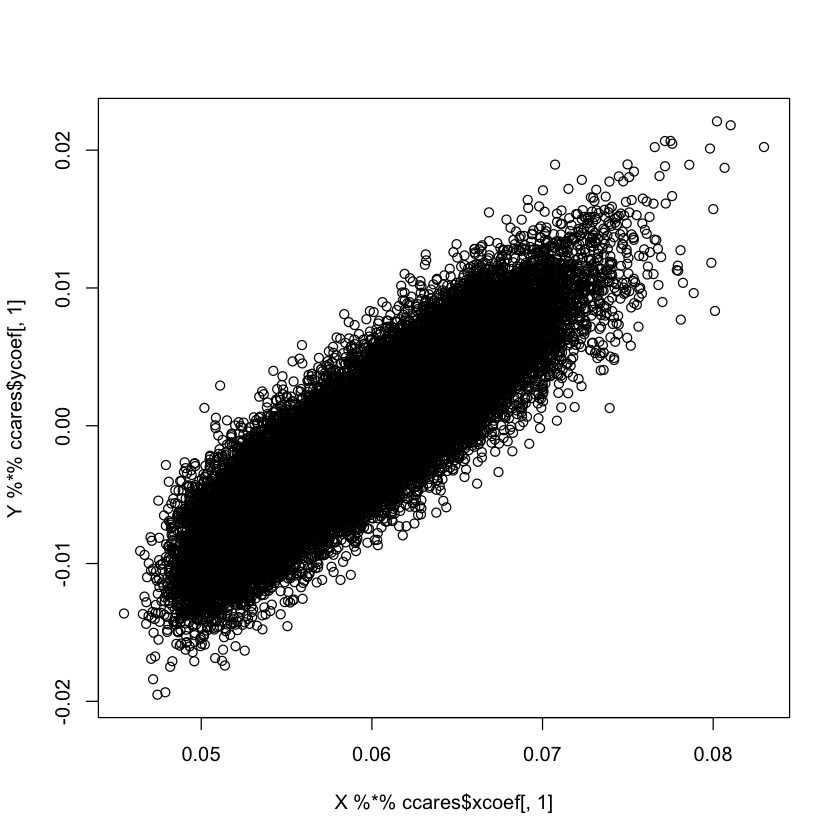

In [114]:
plot(X %*% ccares$xcoef[,1], Y %*% ccares$ycoef[,1]) 

In [115]:
cor(X %*% ccares$xcoef[,1], Y %*% ccares$ycoef[,1])

0.8764725


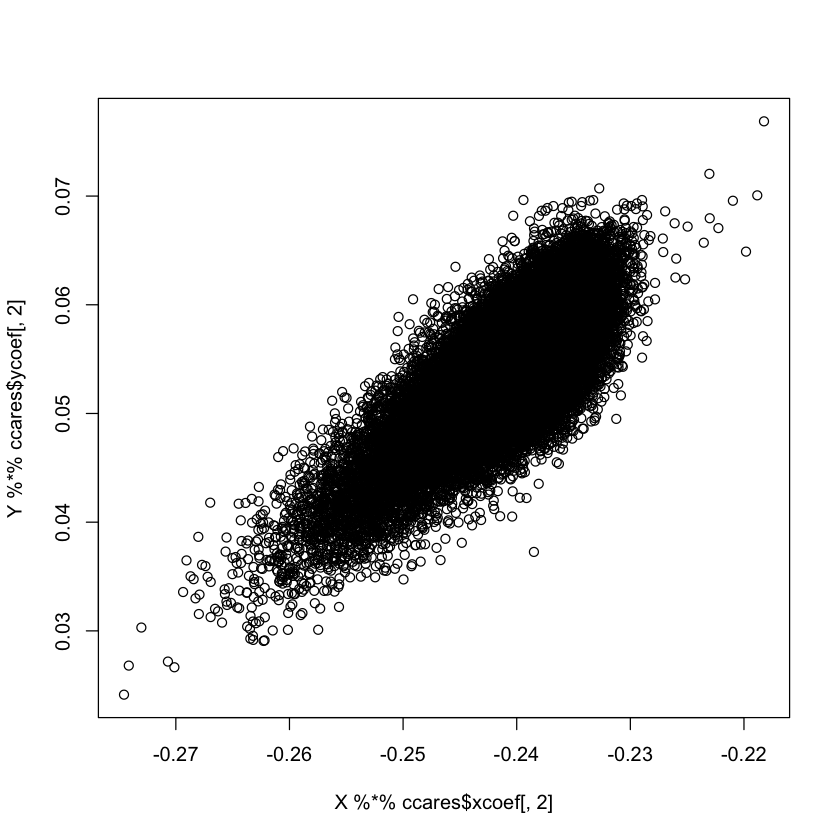

In [116]:
plot(X %*% ccares$xcoef[,2], Y %*% ccares$ycoef[,2]) 

TEMP,4.286940e-04,9.401489e-05,0.0007247133,0.0002707706
PRES,4.904237e-05,-2.330273e-04,0.0009249590,0.0002717908
RAIN,2.080618e-04,5.328091e-04,0.0024710025,-0.0063382877
WSPM,2.284365e-03,-3.362654e-03,-0.0014943825,-0.0006272932


In [7]:
### partition "dat" into three chunks
### --- training
### --- validation: model selection
### --- test: model evaluation
trainix <- seq(from = 1, to = nrow(dat), by = 3)
validix <- seq(from = 2, to = nrow(dat), by = 3)
testix <- seq(from = 3, to = nrow(dat), by = 3)
# training
dat_train <- dat[trainix,]
# validation
dat_valid <- dat[validix,]
# test
dat_test <- dat[testix,]

# Here, we generate design matrices and response vector for the three data subsets (training, validation, testing)
# the function model.matrix is quite useful.  
# It extracts/generates the design matrix ("X") that corresponds to a model formula
Xtrain <- model.matrix(formula(mtr2), data = dat_train)

In [9]:
Xtrain

,(Intercept),TEMP,PRES,RAIN,WSPM,as.factor(wd_coarse)1,as.factor(wd_coarse)2,as.factor(wd_coarse)3,as.factor(wd_coarse)4,as.factor(wd_coarse)5,as.factor(wd_coarse)6,as.factor(wd_coarse)7,WSPM:as.factor(wd_coarse)1,WSPM:as.factor(wd_coarse)2,WSPM:as.factor(wd_coarse)3,WSPM:as.factor(wd_coarse)4,WSPM:as.factor(wd_coarse)5,WSPM:as.factor(wd_coarse)6,WSPM:as.factor(wd_coarse)7
1,1,-0.5,1024.5,0,5.7,0,0,0,1,0,0,0,0.0,0.0,0.0,5.7,0.0,0.0,0.0
4,1,-1.4,1026.2,0,4.9,0,1,0,0,0,0,0,0.0,4.9,0.0,0.0,0.0,0.0,0.0
7,1,-2.5,1028.2,0,2.2,0,0,0,1,0,0,0,0.0,0.0,0.0,2.2,0.0,0.0,0.0
10,1,0.4,1030.5,0,5.5,0,1,0,0,0,0,0,0.0,5.5,0.0,0.0,0.0,0.0,0.0
13,1,4.0,1028.6,0,4.6,-1,-1,-1,-1,-1,-1,-1,-4.6,-4.6,-4.6,-4.6,-4.6,-4.6,-4.6
16,1,6.0,1027.7,0,2.1,0,0,0,1,0,0,0,0.0,0.0,0.0,2.1,0.0,0.0,0.0
19,1,3.2,1029.4,0,0.5,0,0,0,1,0,0,0,0.0,0.0,0.0,0.5,0.0,0.0,0.0
22,1,0.8,1032.4,0,1.0,0,0,1,0,0,0,0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25,1,-0.7,1033.0,0,0.6,1,0,0,0,0,0,0,0.6,0.0,0.0,0.0,0.0,0.0,0.0
28,1,-2.3,1031.3,0,1.5,0,1,0,0,0,0,0,0.0,1.5,0.0,0.0,0.0,0.0,0.0


In [ ]:
ytrain  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% trainix))
colnames(ytrain) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
ntrain <- nrow(ytrain)

Xvalid <- model.matrix(formula(mtr2), data = dat_valid)
yvalid  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% validix))
colnames(yvalid) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
nvalid <- nrow(yvalid)

Xtest <- model.matrix(formula(mtr2), data = dat_test)
ytest  <- subset(log(cbind(dat$PM2.5, dat$PM10, dat$SO2, dat$NO2, dat$CO, dat$O3)), subset = (1:nrow(dat) %in% testix))
colnames(ytest) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
ntest <- nrow(ytest)

q <- ncol(ytrain)
d <- ncol(Xtrain)
# Identity matrix of dimension q
Id_q <- diag(q)

# generate "long" design matrices and "long" response vectors (cf. p. 18 in lecture-05.pdf)
# this is needed to ensure we can run the lasso using the glmnet package (cf. p. 18 in lecture-05.pdf)
Xtrain_long <- matrix(nrow = q * ntrain, ncol = d  * q)
Xvalid_long <- matrix(nrow = q * nvalid, ncol = d  * q)
Xtest_long <- matrix(nrow = q * ntest, ncol = d  * q)
for(i in 1:nrow(Xtrain)){
    Xtrain_long[((i-1)*q + 1):(i*q),] <- kronecker(Xtrain[i,], Id_q)
    Xvalid_long[((i-1)*q + 1):(i*q),] <- kronecker(Xvalid[i,], Id_q)
    Xtest_long[((i-1)*q + 1):(i*q),] <- kronecker(Xtest[i,], Id_q)
}
ytrain_long <- c(t(ytrain))
yvalid_long <- c(t(yvalid))
ytest_long <- c(t(ytest))


# this line compares the coefficients from the matrix representation of the multivariate linear model
# to the coefficients from the long format -- they need to be identical!
#coef(lm(ytrain ~ Xtrain - 1)) - matrix(coef(lm(ytrain_long ~ Xtrain_long - 1)), nrow = d, ncol = q)


# these are the ordinary least regression again -- note that the intercept is already included in 'Xtrain_long'
beta_ols <- coef(lm(ytrain_long ~ Xtrain_long - 1))

#mse_ols <- mean((yvalid_long - Xvalid_long %*% beta_ols)^2)

# baselines to beat: plain OLS and an intercept model (cf. slide 38 in class-04.pdf)
mse_ols <- mean((ytest_long - Xtest_long %*% beta_ols)^2)
mse_intercept <- mean((apply(ytest, MARGIN = 1, STAT = colMeans(ytrain), FUN = "-"))^2)

In [8]:
mse_ols

[1] 0.7586993

,PM2.5,PM10,SO2,NO2,CO,O3
(Intercept),4.337135e+00,4.491804e+00,1.9823090308,4.2482855462,7.2881782019,1.843492e+00
TEMP,-6.932366e-03,-5.006451e-03,-0.0476384053,-0.0151471125,-0.0159424320,5.474069e-02
PRES,5.095343e-05,3.751398e-05,0.0009840802,0.0002522286,0.0001450943,4.766287e-05
RAIN,0.000000e+00,-3.430682e-02,-0.0952634091,-0.0260907232,0.0186141088,0.000000e+00
WSPM,-2.375896e-01,-1.222639e-01,-0.0174240353,-0.2599973983,-0.2233684275,4.446472e-01
as.factor(wd_coarse)1,3.251400e-01,3.374154e-01,0.0040230872,0.1399388450,0.2776259421,-4.351904e-01
as.factor(wd_coarse)2,-5.852758e-02,-1.264368e-01,0.0000000000,0.0000000000,0.0000000000,-1.558920e-01
as.factor(wd_coarse)3,3.027203e-01,2.675028e-01,0.0162009464,0.1023454277,0.2016774940,-4.733052e-01
as.factor(wd_coarse)4,-6.963420e-01,-6.385951e-01,-0.2267420162,-0.2221774494,-0.3953509624,5.595366e-02
as.factor(wd_coarse)5,5.220251e-02,8.430088e-02,0.1309416650,0.0000000000,0.0211854042,3.942290e-01


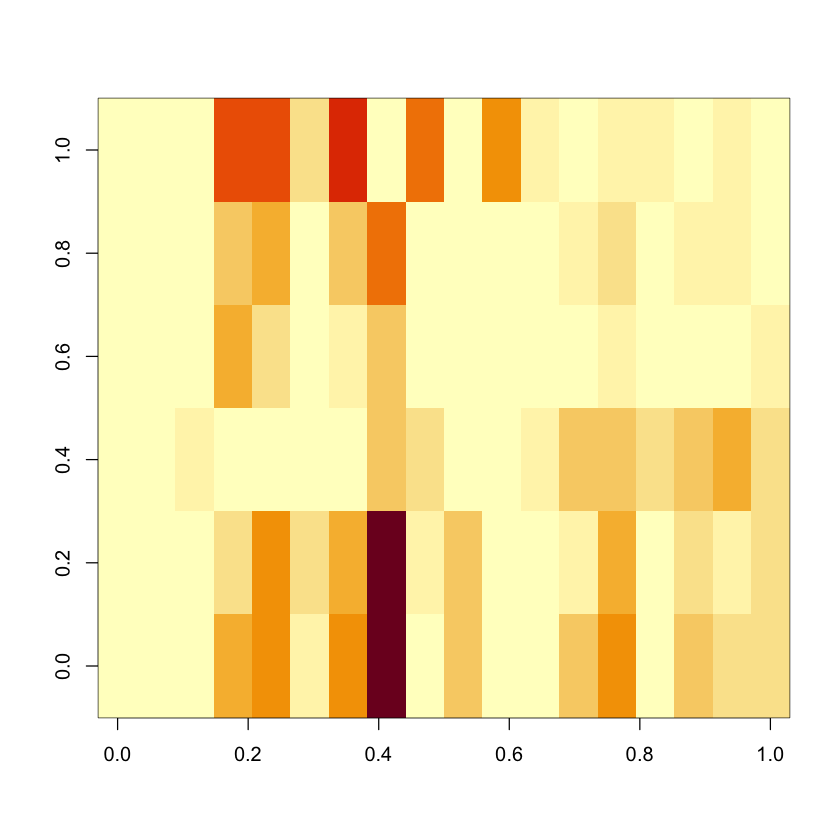

In [9]:
### lasso
# we use the intercepts in Xtrain_long, and do not penalize the corresponding columns
# the glmnet function automatically defines a grid of lambda values and obtains the
# corresponding solutions

lasso_train <- glmnet(x = Xtrain_long, y = ytrain_long, intercept = FALSE,
                      penalty_factor = rep(c(0,rep(1, d- 1)), times = q))

# compute the MSEs on the validation set
mses_valid_lasso <- colMeans((yvalid_long - Xvalid_long %*% lasso_train$beta)^2)
# plot(lasso_train$lambda, mses_valid_lasso) -- we see that the optimal lambda is zero

# compute lasso test error for optimal lambda
lasso_lambdaix <- which.min(mses_valid_lasso)
mses_test_lasso <- mean((ytest_long - Xtest_long %*% lasso_train$beta[,lasso_lambdaix])^2)

# print / visualize the lasso coefficients --- there are indeed some entries exactly equal to zero
Beta_lasso <- matrix(lasso_train$beta[,lasso_lambdaix], nrow = d, ncol = q)
rownames(Beta_lasso) <- colnames(Xtrain)
colnames(Beta_lasso) <- c("PM2.5", "PM10", "SO2", "NO2", "CO", "O3")
image(abs(Beta_lasso[2:d,]))
Beta_lasso

In [10]:
### ridge regression

ridge_train <- glmnet(x = Xtrain_long, y = ytrain_long, intercept = FALSE,
                      penalty_factor = rep(c(0,rep(1, d- 1)), times = q), alpha = 0)

mses_valid_ridge <- colMeans((yvalid_long - Xvalid_long %*% ridge_train$beta)^2)
ridge_lambdaix <- which.min(mses_valid_ridge)
mses_test_ridge <- mean((ytest_long - Xtest_long %*% ridge_train$beta[,ridge_lambdaix])^2)

In [11]:
### group lasso regression

# this may take a few minutes minute or so to run --- this function works with the
# matrix version than with the long version of the data
fit_grpreg <- grpreg(Xtrain[,-1], ytrain, penalty="grLasso",  family= "gaussian",
nlambda=100)

mses_valid_grplasso <- numeric(dim(fit_grpreg$beta)[3])

for(i in 1:dim(fit_grpreg$beta)[3]){
    mses_valid_grplasso[i] <- mean((yvalid - Xvalid %*% t(fit_grpreg$beta[,,i]))^2)
}

# this shows the row sparsity pattern of the solution(s)
t(fit_grpreg$beta[,,10])

# extract test MSE for the value of lamada achieving smallest validation error
grplasso_lambdaix <- which.min(mses_valid_grplasso)
mses_test_grplasso <- mean((ytest - Xtest %*% t(fit_grpreg$beta[,,grplasso_lambdaix]))^2)

(Intercept),4.268397285,4.526522146,2.71482379,4.263376332,7.264370349,2.64965189
TEMP,-0.001224991,-0.001043866,-0.02008299,-0.007709737,-0.007386351,0.02955727
PRES,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
RAIN,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
WSPM,-0.191280313,-0.122885294,-0.10221460,-0.168731907,-0.172320333,0.16437638
as.factor(wd_coarse)1,0.053685351,0.035156006,0.02495090,0.023093596,0.048185084,-0.05836573
as.factor(wd_coarse)2,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)3,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)4,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)5,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000
as.factor(wd_coarse)6,0.000000000,0.000000000,0.00000000,0.000000000,0.000000000,0.00000000


In [12]:
### reduced rank regression

# consider the ranks 1 up to 6 for the coeffcient matrix B
rank_grid <- 1:6
errs_valid_rank <- numeric(length(rank_grid))
errs_test_rank <- numeric(length(rank_grid))

# compute validation and test errors for each value of the rank(1 through 6)
for(r in 1:length(rank_grid)){

    Beta_rr <- rrr(Xtrain[,2:d], ytrain, type = "identity", rank = r)
    errs_valid_rank[r] <- mean((sweep(yvalid, MARGIN = 2, STATS = Beta_rr$mean) - Xvalid[,2:d] %*% t(Beta_rr$C))^2)
    errs_test_rank[r] <- mean((sweep(ytest, MARGIN = 2, STATS = Beta_rr$mean) - Xtest[,2:d] %*% t(Beta_rr$C))^2)

}